In [5]:
!pip install --upgrade transformers huggingface_hub
!pip install fsspec==2025.3.0

In [6]:
!pip install transformers datasets scikit-learn pandas torch

import pandas as pd

train_df = pd.read_csv('train_clean.csv')
val_df = pd.read_csv('val_clean.csv')
test_df = pd.read_csv('test_clean.csv')

train_df = train_df.dropna(subset=['clean_prompt'])
val_df = val_df.dropna(subset=['clean_prompt'])
test_df = test_df.dropna(subset=['clean_prompt'])

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

In [7]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN_BERT = 128

def encode_bert_texts(texts, max_len):
    return bert_tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )

print("Tokenizing data...")
X_train_bert = encode_bert_texts(train_df['clean_prompt'], MAX_LEN_BERT)
X_val_bert = encode_bert_texts(val_df['clean_prompt'], MAX_LEN_BERT)
X_test_bert = encode_bert_texts(test_df['clean_prompt'], MAX_LEN_BERT)

class WildGuardDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = WildGuardDataset(X_train_bert, y_train)
val_dataset = WildGuardDataset(X_val_bert, y_val)
test_dataset = WildGuardDataset(X_test_bert, y_test)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {'macro_f1': macro_f1}

bert_configs = [
    {'learning_rate': 2e-5, 'batch_size': 16},
    {'learning_rate': 3e-5, 'batch_size': 32},
    {'learning_rate': 5e-5, 'batch_size': 16}
]

best_bert_f1 = 0
best_bert_model = None
tuning_log = []

print("Starting BERT Base Tuning Sweeps on GPU...")

for i, config in enumerate(bert_configs):
    config_str = f"lr={config['learning_rate']}, batch_size={config['batch_size']}"
    print(f"\n--- Config {i+1}: [{config_str}] ---")

    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)

    training_args = TrainingArguments(
        output_dir=f'./results_bert_{i}',
        num_train_epochs=2,
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'],
        learning_rate=config['learning_rate'],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    val_macro_f1 = eval_results['eval_macro_f1']

    tuning_log.append(['BERT Base', config_str, val_macro_f1])
    print(f"Result -> Val F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_bert_f1:
        best_bert_f1 = val_macro_f1
        best_bert_model = model

print("\nBERT Tuning Complete.")
tuning_df = pd.DataFrame(tuning_log, columns=['Model', 'Config', 'Val F1'])
display(tuning_df)

print("\nBERT Base Final Test Evaluation: ")
test_trainer = Trainer(model=best_bert_model)
predictions = test_trainer.predict(test_dataset)
test_preds = np.argmax(predictions.predictions, axis=1)

acc = accuracy_score(y_test, test_preds)
macro_f1 = f1_score(y_test, test_preds, average='macro')

print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Macro F1: {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing data...
Starting BERT Base Tuning Sweeps on GPU...

--- Config 1: [lr=2e-05, batch_size=16] ---


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Training Loss,Validation Loss,Epoch,Macro F1
0.076160,0.151721,2,0.959056


Result -> Val F1: 0.9591

BERT Tuning Complete.


,Model,Config,Val F1
0,BERT Base,"lr=2e-05, batch_size=16",0.960539
1,BERT Base,"lr=3e-05, batch_size=32",0.960484
2,BERT Base,"lr=5e-05, batch_size=16",0.959056



BERT Base Final Test Evaluation: 


Test Accuracy: 85.58%
Test Macro F1: 0.8493

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       490
           1       0.83      0.87      0.85       455
           2       0.97      0.78      0.86       413
           3       0.81      0.76      0.78       341

    accuracy                           0.86      1699
   macro avg       0.86      0.85      0.85      1699
weighted avg       0.86      0.86      0.85      1699



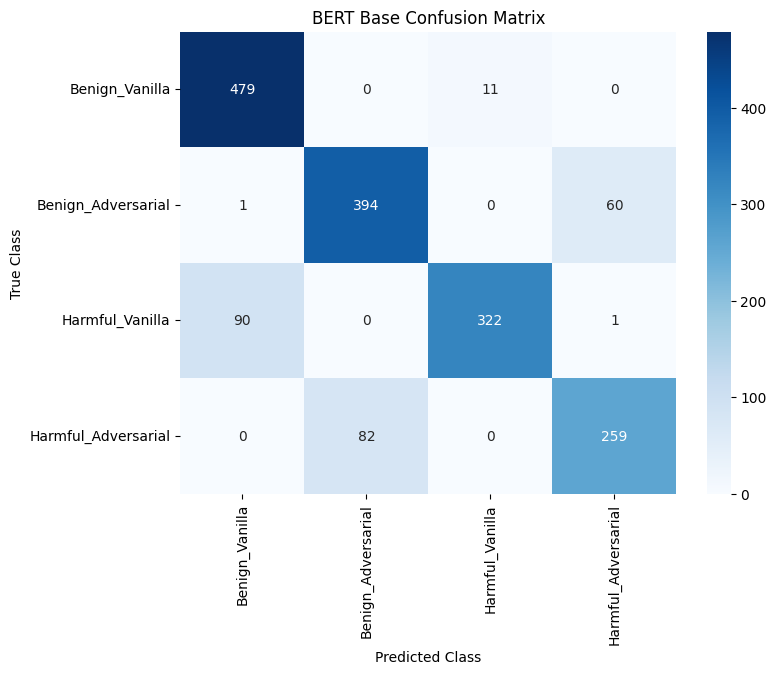

Predictions saved to bert_predictions.csv.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign_Vanilla', 'Benign_Adversarial', 'Harmful_Vanilla', 'Harmful_Adversarial'],
            yticklabels=['Benign_Vanilla', 'Benign_Adversarial', 'Harmful_Vanilla', 'Harmful_Adversarial'])
plt.title('BERT Base Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

bert_predictions_df = pd.DataFrame({'bert_preds': test_preds})
bert_predictions_df.to_csv('bert_predictions.csv', index=False)
print("Predictions saved to bert_predictions.csv.")